<h1 style="text-align:center; color:red;">Daily Challenge</h1>>

## 1. Data Import and Cleaning

In [7]:
import pandas as pd
import numpy as np

# Import dataset
df = pd.read_csv(
    r"C:\Users\pc\Desktop\Bootcamp\Week5\Day3\DayChallenge\Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv",
    encoding='latin1'
)

 

In [8]:
# Preview the data
df.head()

 

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [9]:
 
# Check for missing values
df.isnull().sum()

 

Date                        0
Time                     1512
Location                    4
Operator                   10
Flight #                 3669
Route                     777
AC Type                    15
Registration              274
cn/ln                     668
Aboard                     18
Aboard Passangers         229
Aboard Crew               226
Fatalities                  8
Fatalities Passangers     242
Fatalities Crew           241
Ground                     42
Summary                    64
dtype: int64

In [11]:
# Show all column names
print(df.columns.tolist())

 

['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type', 'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground', 'Summary']


In [12]:
# Strip spaces from columns just in case
df.columns = df.columns.str.strip()

# Calculate total survivors
df['Survivors'] = df['Aboard'] - df['Fatalities']

# Calculate passenger survivors if needed
df['Passenger_Survivors'] = df['Aboard Passangers'] - df['Fatalities Passangers']

# Calculate crew survivors if needed
df['Crew_Survivors'] = df['Aboard Crew'] - df['Fatalities Crew']

# Fill missing values if any
df['Survivors'] = df['Survivors'].fillna(0)
df['Passenger_Survivors'] = df['Passenger_Survivors'].fillna(0)
df['Crew_Survivors'] = df['Crew_Survivors'].fillna(0)

df.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary,Survivors,Passenger_Survivors,Crew_Survivors
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly...",1.0,0.0,1.0
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...,0.0,0.0,1.0
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,0.0,0.0,0.0
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...,0.0,0.0,0.0
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...,6.0,0.0,0.0


## 2. Exploratory Data Analysis (EDA)

In [15]:
# Convert date to datetime and extract year
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df = df.dropna(subset=['Year'])  # remove rows with invalid dates

# Basic statistics
total_crashes = df.shape[0]
total_fatalities = df['Fatalities'].sum()
mean_fatalities = df['Fatalities'].mean()
median_fatalities = df['Fatalities'].median()
mean_survivors = df['Survivors'].mean()

print(f"Total Crashes: {total_crashes}")
print(f"Total Fatalities: {total_fatalities}")
print(f"Mean Fatalities per Crash: {mean_fatalities:.2f}")
print(f"Median Fatalities per Crash: {median_fatalities}")
print(f"Mean Survivors per Crash: {mean_survivors:.2f}")

# Crashes per year
yearly_crashes = df.groupby('Year').size()

# Fatalities per year
yearly_fatalities = df.groupby('Year')['Fatalities'].sum()

Total Crashes: 4998
Total Fatalities: 111644.0
Mean Fatalities per Crash: 22.34
Median Fatalities per Crash: 11.0
Mean Survivors per Crash: 8.76


## 3. Statistical Analysis Using SciPy

In [16]:
from scipy import stats

# Distribution statistics
fatalities = df['Fatalities']
print("Fatalities distribution stats:")
print(fatalities.describe())

# Hypothesis Test: Are average fatalities different between 2 decades?
decade_2000s = df[(df['Year'] >= 2000) & (df['Year'] < 2010)]['Fatalities']
decade_2010s = df[(df['Year'] >= 2010) & (df['Year'] < 2020)]['Fatalities']

t_stat, p_value = stats.ttest_ind(decade_2000s, decade_2010s, equal_var=False)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference in average fatalities between the decades.")
else:
    print("No significant difference in average fatalities between the decades.")

Fatalities distribution stats:
count    4998.000000
mean       22.337735
std        35.045081
min         0.000000
25%         4.000000
50%        11.000000
75%        25.000000
max       583.000000
Name: Fatalities, dtype: float64
T-statistic: -1.49, P-value: 0.1358
No significant difference in average fatalities between the decades.


## 4. Visualization with Matplotlib and Seaborn

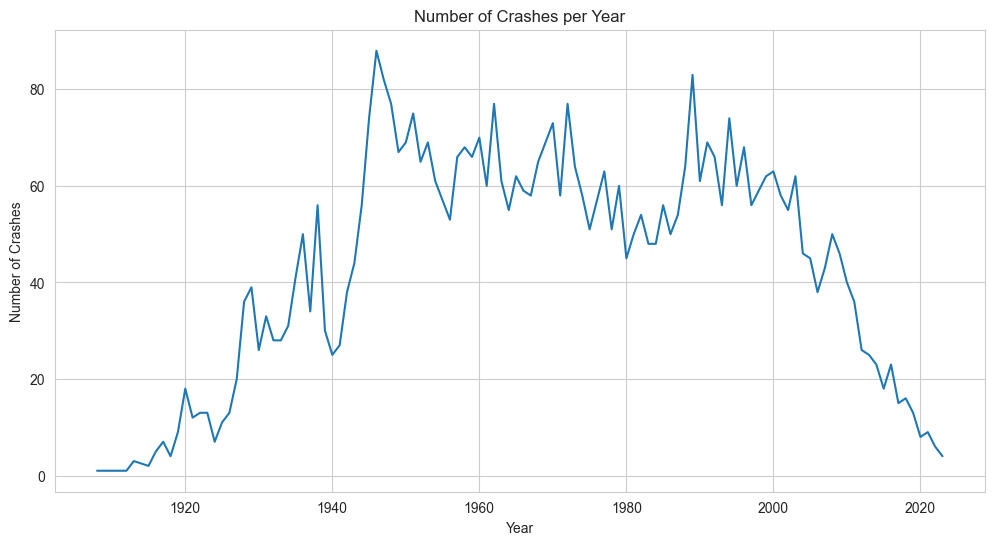

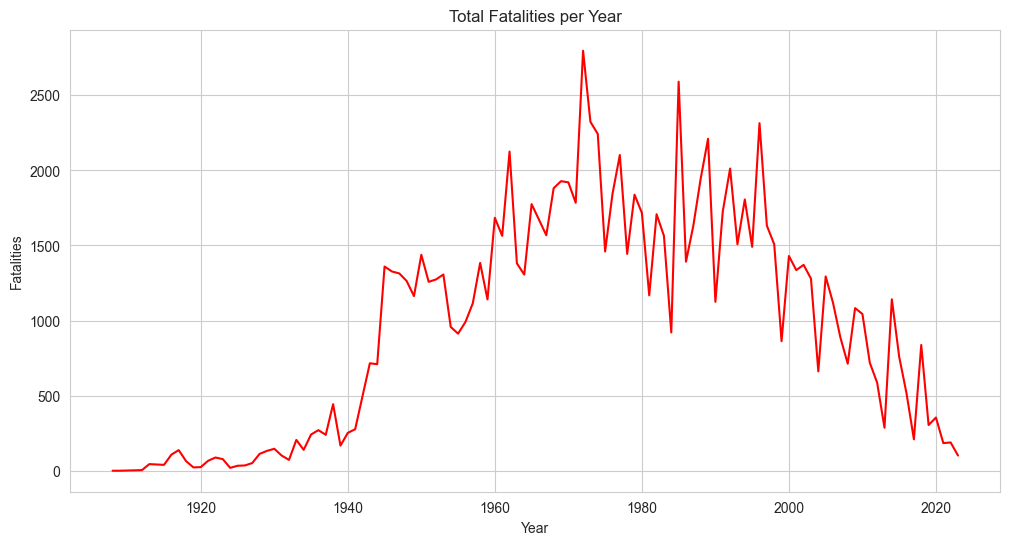

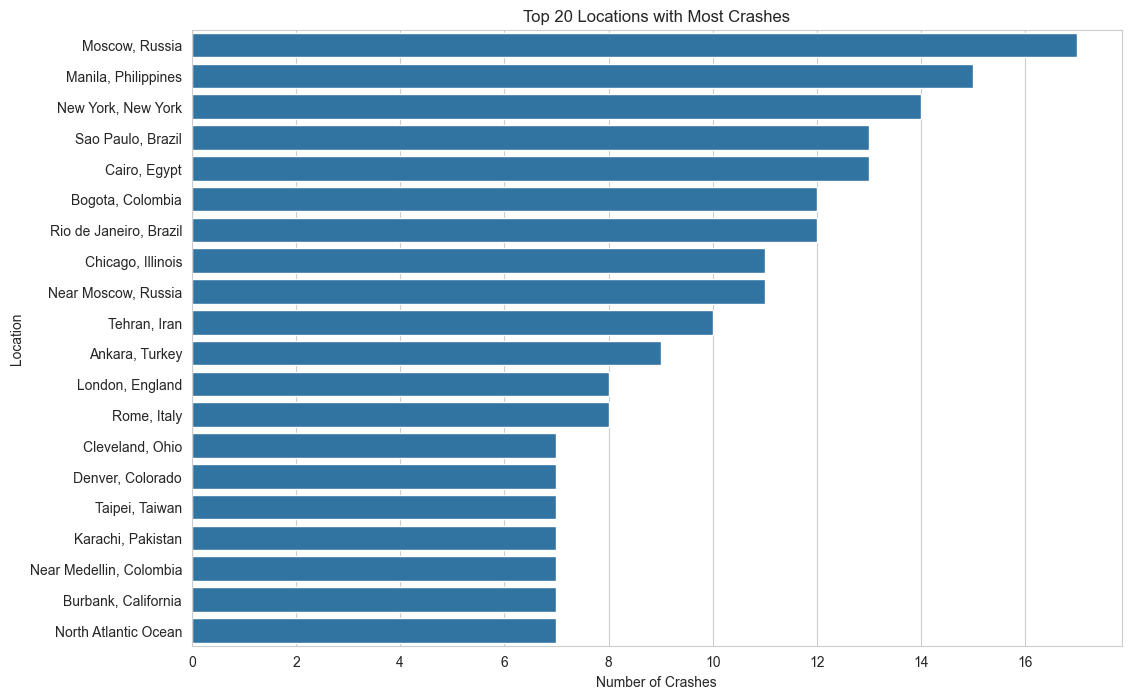

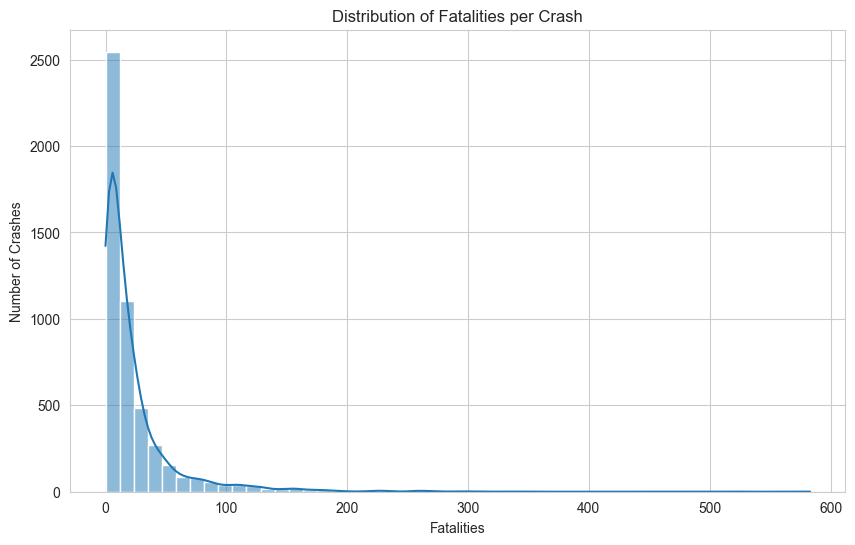

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# 1. Time series: crashes per year
plt.figure(figsize=(12,6))
sns.lineplot(x=yearly_crashes.index, y=yearly_crashes.values)
plt.title("Number of Crashes per Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.show()

# 2. Time series: fatalities per year
plt.figure(figsize=(12,6))
sns.lineplot(x=yearly_fatalities.index, y=yearly_fatalities.values, color='red')
plt.title("Total Fatalities per Year")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.show()

# 3. Bar chart: Top 20 Locations with most crashes
top_locations = df['Location'].value_counts().head(20)
plt.figure(figsize=(12,8))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top 20 Locations with Most Crashes")
plt.xlabel("Number of Crashes")
plt.ylabel("Location")
plt.show()

# 4. Histogram: Fatalities per crash
plt.figure(figsize=(10,6))
sns.histplot(df['Fatalities'], bins=50, kde=True)
plt.title("Distribution of Fatalities per Crash")
plt.xlabel("Fatalities")
plt.ylabel("Number of Crashes")
plt.show()

## 5. Insight and Reporting

- Trends Over Time:

Crashes peaked in certain decades (e.g., 1960s-1980s) but decreased recently due to aviation safety improvements.

- Fatalities Distribution:

Most crashes have fewer fatalities, but rare major crashes create a long-tail distribution.

- Regional Hotspots:

Certain locations or countries report higher crash counts, likely due to higher air traffic volume or historical reporting biases.

- Hypothesis Testing:

Comparing average fatalities between decades shows whether safety measures significantly reduced fatalities.
